In [1]:
import os
import numpy as np
import scipy.stats as sps
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils import prune
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from tqdm import tqdm
import pickle
from utils import get_network_tinyimagenet
from conf import settings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
import copy
import random
seed = 0

gpu = 'cuda:0'
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
random.seed(seed)
torch.backends.cudnn.deterministic=True

In [2]:
subset1_mean, subset1_std = settings.TINYIMAGENET_SUBTRAIN_MEAN[0], settings.TINYIMAGENET_SUBTRAIN_STD[0]

def load_model(path, norm=False, dev='cpu'):
    vic = get_network_tinyimagenet('mobilenet_v2', False).to(dev)
    vic.load_state_dict(torch.load(path, map_location=dev))
    vic.eval()
    if norm:
        return nn.Sequential(transforms.Normalize(subset1_mean, subset1_std), vic)
    return vic

In [3]:
def global_prune(net, p=0.2):
    copy_net = copy.deepcopy(net)
    parameters_to_prune = []
    for name, module in copy_net.named_modules():
        if isinstance(module, torch.nn.Conv2d):
            parameters_to_prune.append((module, 'weight'))
        if isinstance(module, torch.nn.Linear):
            parameters_to_prune.append((module, 'weight'))
    prune.global_unstructured(
        tuple(parameters_to_prune),
        pruning_method=prune.L1Unstructured,
        amount=p,
    )
    return copy_net

# Paths

In [24]:
root_path = '/data1/checkpoint/'
related_folder_path = os.path.join(root_path, 'hash/tinyimagenet/')
unrelated_folder_path = os.path.join(root_path, 'hash/tinyimagenet/independent')

original_path = os.path.join(related_folder_path, 'mobilenet_v2_0.pth')
quant_path = os.path.join(related_folder_path, 'mobilenet_v2_0_quant.pth')

finetune_path_dict = {}
# for fid in range(5):
#     folder_name = 'finetune_{}'.format(fid)
#     finetune_path_dict[folder_name] = [
#         os.path.join(related_folder_path, '{}/finetune_{}.pth'.format(folder_name, i)) for i in range(1, 11)]
#     folder_name = 'advfinetune_{}'.format(fid)
#     finetune_path_dict[folder_name] = [
#         os.path.join(related_folder_path, '{}/finetune_{}.pth'.format(folder_name, i)) for i in range(1, 11)]

for fid in range(5, 10):
    folder_name = 'finetune_{}'.format(fid)
    finetune_path_dict[folder_name] = [
        os.path.join(related_folder_path, '{}/finetune_{}.pth'.format(folder_name, i)) for i in range(1, 21)]
    folder_name = 'advfinetune_{}'.format(fid)
    finetune_path_dict[folder_name] = [
        os.path.join(related_folder_path, '{}/finetune_{}.pth'.format(folder_name, i)) for i in range(1, 21)]

unrelated_path_list = [os.path.join(unrelated_folder_path, 'model_{}.pth'.format(i)) for i in range(200)]

In [25]:
original_net = load_model(original_path, norm=True, dev='cpu')
orig_net_params = dict(original_net.named_parameters())

In [26]:
diff_indep = []
for path in unrelated_path_list:
    net = load_model(path, norm=True, dev='cpu')
    net_params = dict(net.named_parameters())
    for k in orig_net_params.keys():
        tmp = 0
        tmp += torch.sqrt(torch.sum((orig_net_params[k] - net_params[k])**2)).item()
    diff_indep.append(tmp)

In [27]:
np.min(diff_indep)

0.2035195380449295

In [33]:
diff_finetune = []
finetune_param_diff_dict = {"diff":[], 'Finetuned Epoch':[], 'copy':[], 'Type':[]}
for ft_copy, ft_path_list in finetune_path_dict.items():
    print(ft_copy)
    for ft_epoch, path in enumerate(ft_path_list):
        net = load_model(path, norm=True, dev='cpu')
        net_params = dict(net.named_parameters())
        for k in orig_net_params.keys():
            tmp = 0
            tmp += torch.sqrt(torch.sum((orig_net_params[k] - net_params[k])**2)).item()
        diff_finetune.append(tmp)
        finetune_param_diff_dict['diff'].append(tmp)
        finetune_param_diff_dict['Finetuned Epoch'].append(ft_epoch + 1)
        finetune_param_diff_dict['copy'].append(ft_copy)
        if 'adv' in ft_copy:
            finetune_param_diff_dict['Type'].append('adv')
        else:
            finetune_param_diff_dict['Type'].append('normal')

finetune_5
advfinetune_5
finetune_6
advfinetune_6
finetune_7
advfinetune_7
finetune_8
advfinetune_8
finetune_9
advfinetune_9


In [34]:
np.max(diff_finetune)

0.0014473623596131802

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [36]:
finetune_param_diff_dict.keys()

dict_keys(['diff', 'Finetuned Epoch', 'copy', 'Type'])

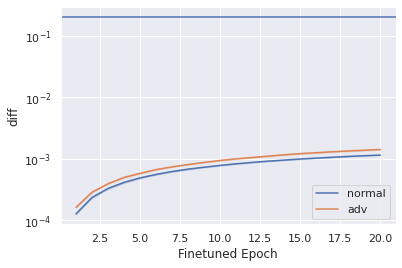

In [38]:
df = pd.DataFrame.from_dict(finetune_param_diff_dict)
sns.set_theme(style="darkgrid")
sns.lineplot(data =df,x='Finetuned Epoch', y='diff', hue='Type')
plt.axhline(y=np.min(diff_indep))
plt.yscale("log")
plt.legend()
plt.show()

In [39]:
import pickle
pickle.dump((df, np.min(diff_indep)), open("tiny_real_weight_diff_df.pkl","wb"))